In [1]:
import json
import os

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import stft
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq, Qwen2VLForConditionalGeneration, AutoProcessor, AutoTokenizer
import torch


/home/hbw/miniconda3/envs/diffuser/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# print("test:")

# with h5py.File("resource/test_public.h5", "r") as f:
#     print("Keys in file:", list(f.keys()))

#     questions = np.array(f["questions"])
#     print(f"questions shape: {questions.shape}")
#     print(f"First few rows: {questions[:5]}")

#     waveforms = np.array(f["waveforms"])
#     print(f"waveform shape: {waveforms.shape}")
#     print(f"waveforms: {waveforms[0]}")

DATASET_DIR = "airadio/train_1k"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")

print("train:")
NUM_TRAIN = 1000

# 使用 split.py 划分一个小数据集
with h5py.File("resource/train_1k.h5", "r") as f:
    print("Keys in file:", list(f.keys()))

    labels = np.array(f["labels"])[:NUM_TRAIN]
    print(f"labels shape: {labels.shape}")
    print(f"First few rows: {labels[:5]}")

    waveforms = np.array(f["waveforms"])[:NUM_TRAIN]
    print(f"waveform shape: {waveforms.shape}")
    print(f"waveforms: {waveforms[0]}")


train:
Keys in file: ['labels', 'waveforms']
labels shape: (1000,)
First few rows: [b'[[2427.0, 2447.0], [2422.0, 2432.0], [2422.0, 2432.0], [2427.0, 2447.0]]'
 b'[[2432.0, 2442.0], [2402.0, 2412.0]]'
 b'[[2423.875, 2424.125], [2420.875, 2421.125], [2455.0, 2457.0]]'
 b'[[2422.0, 2462.0], [2402.0, 2442.0]]'
 b'[[2451.0, 2453.0], [2406.875, 2407.125], [2437.0, 2477.0], [2431.0, 2433.0]]']
waveform shape: (1000, 100000)
waveforms: [ 3633.75   +1094.75j    1841.57   -2087.903j   -978.80225-1032.3933j ...
  3684.816  +1735.1885j  2502.5044 -1987.3585j -1170.4862 -1967.5258j]


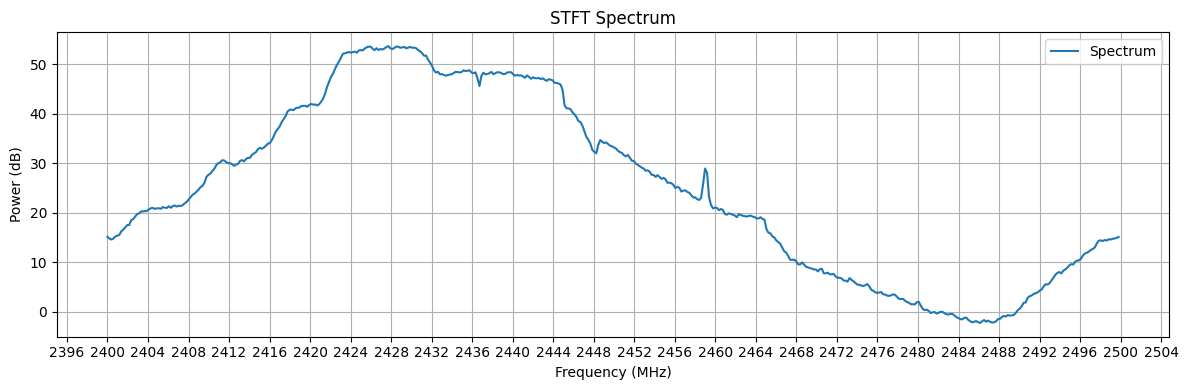

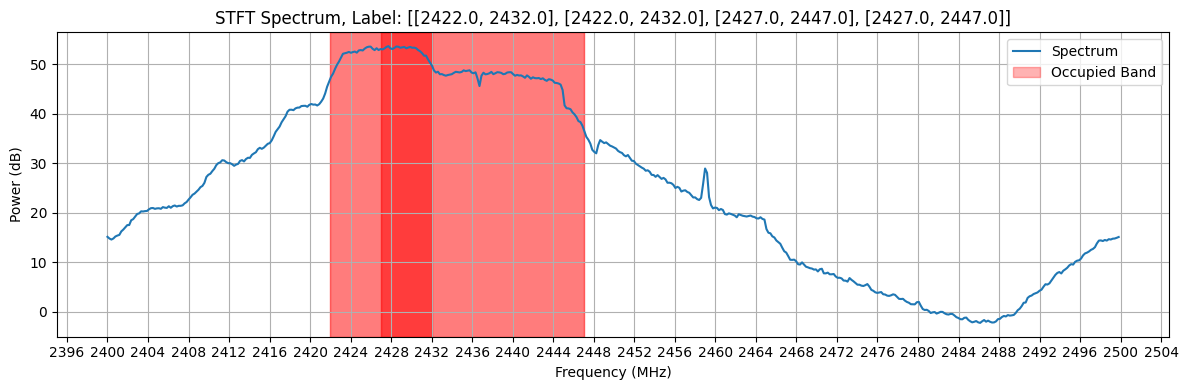

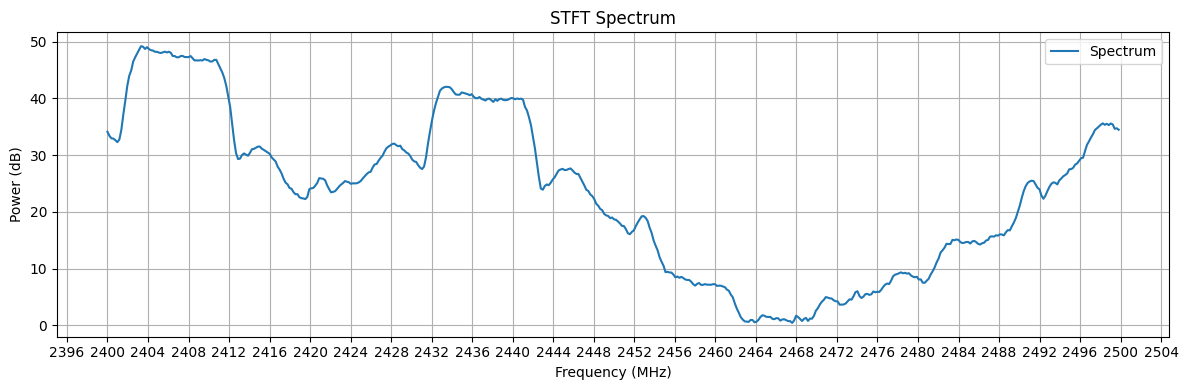

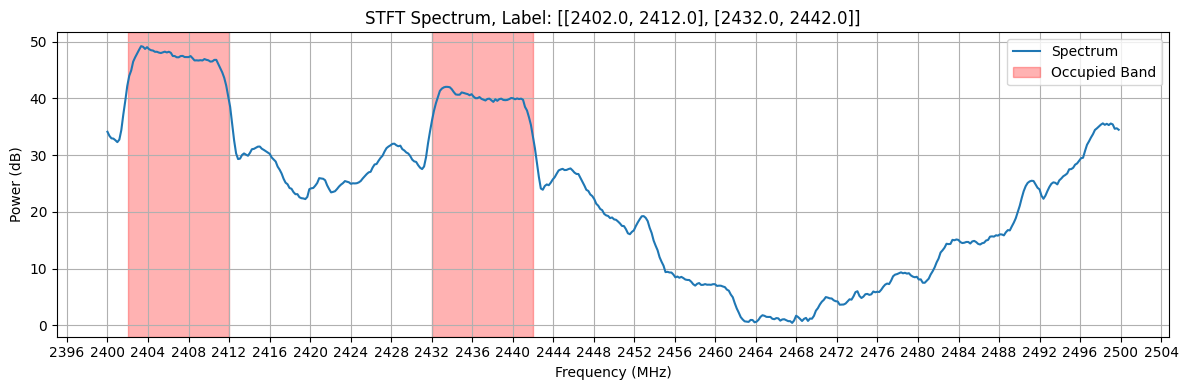

In [3]:
def plot_fft(iq_data, label_str, idx, fs=100e6, f_start=2400e6, f_end=2500e6, show=False, dataset_version="train"):
    """
    对单个 IQ 样本进行 FFT 并可视化为频率域图像。

    参数：
        iq_data (np.array): 一维复数数组，表示 IQ 采样数据。
        label_str (str): 标签字符串，格式如 '[[2402.0, 2422.0], ...]'。
        idx (int): 样本索引，用于文件命名。
        fs (float): 采样率（Hz）
        f_start (float): 起始频率（Hz）
        f_end (float): 结束频率（Hz）
    """
    N = len(iq_data)
    freqs = np.linspace(f_start, f_end, N)

    # FFT 计算并移位
    window = np.hanning(N)
    spectrum = np.fft.fft(iq_data * window)
    spectrum = np.fft.fftshift(spectrum)

    # 转换为 MHz 显示
    freqs_mhz = freqs / 1e6
    magnitude = np.abs(spectrum)

    # frequencies, times, Zxx = stft(iq_data, window='hann', nperseg=N)
    # freqs_mhz = frequencies / 1e6
    # magnitude = np.abs(Zxx)

    # 解析标签
    occupied_bands = sorted(eval(label_str.tobytes()))

    # 绘图
    plt.figure(figsize=(12, 4))
    plt.plot(freqs_mhz, magnitude, label="Spectrum")

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude")

    if dataset_version == "vis":
        for band in occupied_bands:
            plt.axvspan(band[0], band[1], color='red', alpha=0.3, label="Occupied Band")

        plt.title(f"Frequency Domain Spectrum, Label: {occupied_bands}")
    else:
        plt.title(f"Frequency Domain Spectrum")

    plt.grid(True)

    # 去重图例
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    # 增加 x 轴刻度
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(4))

    plt.tight_layout()
    if not os.path.exists(IMAGE_DIR):
        os.makedirs(IMAGE_DIR)
    if not os.path.exists(os.path.join(IMAGE_DIR, dataset_version)):
        os.makedirs(os.path.join(IMAGE_DIR, dataset_version))
    image_path = os.path.join(IMAGE_DIR, dataset_version, f"spectrum_{idx}.png")
    plt.savefig(image_path)
    if show:
        plt.show()
    plt.close()


def plot_fft_v2(iq_data, label_str, idx, fs=100e6, f_start=2400e6, f_end=2500e6, show=False, dataset_version="train"):
    """
    对单个 IQ 样本进行 STFT 并可视化为频率域图像。

    参数：
        iq_data (np.array): 一维复数数组，表示 IQ 采样数据。
        label_str (str): 标签字符串，格式如 '[[2402.0, 2422.0], ...]'。
        idx (int): 样本索引，用于文件命名。
        fs (float): 采样率（Hz）
        f_start (float): 起始频率（Hz）
        f_end (float): 结束频率（Hz）
        show (bool): 是否显示图像
        dataset_version (str): 数据集版本名（如 "train" 或 "vis"）
        IMAGE_DIR (str): 图像保存路径
    """

    N = len(iq_data)
    window_size = min(1024, N // 8)  # 设置合适的窗口长度
    window_size = 512

    # 计算 STFT
    frequencies, times, Zxx = stft(iq_data, fs=fs, nperseg=window_size, noverlap=window_size // 2, window='hann', return_onesided=False)

    # 将频率轴从 Hz 转换为 MHz
    center_freq = (f_start + f_end) / 2
    freqs_mhz = (frequencies + center_freq) / 1e6

    # 移位，使频率轴对称中心为 DC（直流）
    shift_idx = len(frequencies) // 2
    freqs_mhz = np.roll(freqs_mhz, shift_idx)
    magnitude = 10 * np.log10((np.abs(np.roll(Zxx, shift_idx, axis=0)) ** 2).mean(axis=1))

    # 解析标签
    try:
        occupied_bands = sorted(eval(label_str.tobytes()))
    except:
        occupied_bands = []

    # 绘图
    plt.figure(figsize=(12, 4))
    plt.plot(freqs_mhz, magnitude, label="Spectrum")

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Power (dB)")

    if dataset_version == "vis" and occupied_bands:
        for band in occupied_bands:
            plt.axvspan(band[0], band[1], color='red', alpha=0.3, label="Occupied Band")

        plt.title(f"STFT Spectrum, Label: {occupied_bands}")
    else:
        plt.title(f"STFT Spectrum")

    plt.grid(True)

    # 去重图例
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    # 增加 x 轴刻度
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(4))

    plt.tight_layout()

    # 确保目录存在
    if not os.path.exists(IMAGE_DIR):
        os.makedirs(IMAGE_DIR)
    version_dir = os.path.join(IMAGE_DIR, dataset_version)
    if not os.path.exists(version_dir):
        os.makedirs(version_dir)

    image_path = os.path.join(version_dir, f"spectrum_{idx}.png")
    plt.savefig(image_path)
    if show:
        plt.show()
    plt.close()


NUM_VISUALIZE = 10
for i in range(NUM_VISUALIZE):
    label_str = labels[i]
    waveform = waveforms[i]
    plot_fft_v2(waveform, label_str, i, show=i<2, dataset_version="train")
    plot_fft_v2(waveform, label_str, i, show=i<2, dataset_version="vis")
    print(f"Processed {i + 1}/{NUM_VISUALIZE} samples.", end="\r")


In [4]:
# 生成数据集

FINETUNE_PROMPT = r"""## 描述

这是一张 IQ 采样数据的可视化图片，表示在2400 MHz到2500 MHz频段内以100 MS/s采样率采集的信号。该频段内存在多个信号（2到4个）。这些信号可能频域上存在重叠，表示信号之间的干扰。

## 任务

1. 请观察图片，一步步地推导出占用频段的区间范围
2. 请考虑占用区间不在图中标注出来的数字
3. 占用频段的区间范围是指在2400 MHz – 2483.5 MHz范围内，信号的频率范围
4. 按照 [[start_0, end_0], [start_1, end_1], ..., [start_n, end_n]] 的格式输出结果
"""

REGENERATE = False
NUM_TRAIN = 900
NUM_VALIDATE = 100
conversations_train = []
conversations_validate = []

def generate_sample(idx, path, label):
    path = os.path.abspath(path)
    return dict(
        id=f"identity_{idx}",
        conversations=[
            {
                "from": "user",
                "value": f"<|vision_start|>{path}<|vision_end|>\n{FINETUNE_PROMPT}",
            },
            {
                "from": "assistant",
                "value": label,
            }
        ]
    )

for i in range(NUM_TRAIN):
    label_str = labels[i]
    waveform = waveforms[i]
    image_path = os.path.join(IMAGE_DIR, "train", f"spectrum_{i}.png")
    if REGENERATE or not os.path.exists(image_path):
        plot_fft(waveform, label_str, i, dataset_version="train")
    label = str(sorted(eval(label_str.tobytes())))
    conversations_train.append(generate_sample(i, image_path, label))

for i in range(NUM_VALIDATE):
    j = NUM_TRAIN + i
    label_str = labels[j]
    waveform = waveforms[j]
    image_path = os.path.join(IMAGE_DIR, "val", f"spectrum_{j}.png")
    if REGENERATE or not os.path.exists(image_path):
        plot_fft(waveform, label_str, j, dataset_version="val")
    label = str(sorted(eval(label_str.tobytes())))
    conversations_validate.append(generate_sample(j, image_path, label))

with open('data_vl_train.json', 'w', encoding='utf-8') as f:
    json.dump(conversations_train, f, ensure_ascii=False, indent=2)

with open('data_vl_val.json', 'w', encoding='utf-8') as f:
    json.dump(conversations_validate, f, ensure_ascii=False, indent=2)


In [5]:
# 使用Transformers加载模型权重
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-VL-2B-Instruct", use_fast=False, trust_remote_code=True)
# 特别的，Qwen2-VL-2B-Instruct模型需要使用Qwen2VLForConditionalGeneration来加载
model = Qwen2VLForConditionalGeneration.from_pretrained("Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, trust_remote_code=True)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")
model.enable_input_require_grads()  # 开启梯度检查点时，要执行该方法

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  8.40it/s]


In [16]:
import torch
from datasets import Dataset
from qwen_vl_utils import process_vision_info
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
)
import json

def process_func(example):
    """
    将数据集进行预处理
    """
    MAX_LENGTH = 8192
    input_ids, attention_mask, labels = [], [], []
    conversation = example["conversations"]
    input_content = conversation[0]["value"]
    output_content = conversation[1]["value"]
    file_path = input_content.split("<|vision_start|>")[1].split("<|vision_end|>")[0]  # 获取图像路径
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"{file_path}",
                    "resized_height": 280,
                    "resized_width": 280,
                },
                {"type": "text", "text": FINETUNE_PROMPT},
            ],
        }
    ]
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )  # 获取文本
    image_inputs, video_inputs = process_vision_info(messages)  # 获取数据数据（预处理过）
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {key: value.tolist() for key, value in inputs.items()} #tensor -> list,为了方便拼接
    instruction = inputs

    response = tokenizer(f"{output_content}", add_special_tokens=False)


    input_ids = (
            instruction["input_ids"][0] + response["input_ids"] + [tokenizer.pad_token_id]
    )

    attention_mask = instruction["attention_mask"][0] + response["attention_mask"] + [1]
    labels = (
            [-100] * len(instruction["input_ids"][0])
            + response["input_ids"]
            + [tokenizer.pad_token_id]
    )
    if len(input_ids) > MAX_LENGTH:  # 做一个截断
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]

    input_ids = torch.tensor(input_ids)
    attention_mask = torch.tensor(attention_mask)
    labels = torch.tensor(labels)
    inputs['pixel_values'] = torch.tensor(inputs['pixel_values'])
    inputs['image_grid_thw'] = torch.tensor(inputs['image_grid_thw']).squeeze(0)  #由（1,h,w)变换为（h,w）
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels,
            "pixel_values": inputs['pixel_values'], "image_grid_thw": inputs['image_grid_thw']}

# 处理数据集：读取json文件
# 拆分成训练集和测试集，保存为data_vl_train.json和data_vl_test.json
train_ds = Dataset.from_json("data_vl_train.json")
train_dataset = train_ds.map(process_func)

# 配置LoRA
config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    inference_mode=False,  # 训练模式
    r=64,  # Lora 秩
    lora_alpha=16,  # Lora alaph，具体作用参见 Lora 原理
    lora_dropout=0.05,  # Dropout 比例
    bias="none",
)

# 获取LoRA模型
peft_model = get_peft_model(model, config)

# 配置训练参数
args = TrainingArguments(
    output_dir="output/Qwen2-VL-2B",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    logging_steps=10,
    num_train_epochs=2,
    save_steps=100,
    learning_rate=1e-4,
    save_on_each_node=True,
    gradient_checkpointing=True,
    report_to="none",
)
        
# 配置Trainer
trainer = Trainer(
    model=peft_model,
    args=args,
    train_dataset=train_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
)
# 开启模型训练
trainer.train()


Generating train split: 900 examples [00:00, 14897.48 examples/s]
Map: 100%|██████████| 900/900 [00:45<00:00, 19.60 examples/s]
/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.10/site-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
  2%|▏         | 10/450 [01:33<1:11:33,  9.76s/it]

{'loss': 0.9399, 'grad_norm': 0.798367440700531, 'learning_rate': 9.777777777777778e-05, 'epoch': 0.04}


  4%|▍         | 20/450 [02:49<51:33,  7.19s/it]  

{'loss': 0.5455, 'grad_norm': 0.44149717688560486, 'learning_rate': 9.555555555555557e-05, 'epoch': 0.09}


  7%|▋         | 30/450 [04:22<59:19,  8.48s/it]  

...

{'loss': 0.308, 'grad_norm': 0.580396831035614, 'learning_rate': 5.333333333333333e-05, 'epoch': 0.93}


 49%|████▉     | 220/450 [27:31<24:00,  6.26s/it]

{'loss': 0.3183, 'grad_norm': 0.6963832378387451, 'learning_rate': 5.111111111111111e-05, 'epoch': 0.98}


 50%|████▉     | 223/450 [27:50<24:18,  6.42s/it]

KeyboardInterrupt: 

In [17]:
model.device


device(type='mps', index=0)

In [19]:
def predict(messages, model):
    # 准备推理
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("mps")

    # 生成输出
    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    return output_text[0]


# ===测试模式===
# 配置测试参数
val_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    inference_mode=True,  # 训练模式
    r=64,  # Lora 秩
    lora_alpha=16,  # Lora alaph，具体作用参见 Lora 原理
    lora_dropout=0.05,  # Dropout 比例
    bias="none",
)

# 获取测试模型
val_peft_model = PeftModel.from_pretrained(model, model_id="./output/Qwen2-VL-2B/checkpoint-200", config=val_config)

# 读取测试数据
with open("data_vl_val.json", "r") as f:
    test_dataset = json.load(f)

test_image_list = []
radio_predcitions = []
for item in test_dataset:
    input_image_prompt = item["conversations"][0]["value"]
    # 去掉前后的<|vision_start|>和<|vision_end|>
    origin_image_path = input_image_prompt.split("<|vision_start|>")[1].split("<|vision_end|>")[0]
    print(origin_image_path)
    
    messages = [{
        "role": "user", 
        "content": [
            {
                "type": "image",
                "image": f"{origin_image_path}"
            },
            {
                "type": "text", 
                "text": FINETUNE_PROMPT,
            },
        ]}]
    
    response = predict(messages, val_peft_model)
    messages.append({"role": "assistant", "content": f"{response}"})
    print(messages[-1])

    radio_predcitions.append(
        dict(image_path=origin_image_path, prediction=messages[-1]["content"])
    )

with open("data_vl_val_predictions.json", "w") as f:
    json.dump(radio_predcitions, f, indent=4, ensure_ascii=False)


/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_900.png


/opt/homebrew/Caskroom/miniforge/base/envs/torch/lib/python3.10/site-packages/transformers/pytorch_utils.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


{'role': 'assistant', 'content': '[[2422.0, 2462.0], [2462.0, 2472.0]]'}
/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_901.png
{'role': 'assistant', 'content': '[[2427.0, 2437.0], [2432.0, 2452.0], [2442.0, 2452.0], [2452.0, 2472.0]]'}
/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_902.png
{'role': 'assistant', 'content': '[[2427.0, 2429.0], [2432.0, 2442.0], [2432.0, 2472.0], [2472.0, 2482.0]]'}
/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_903.png
{'role': 'assistant', 'content': '[[2407.0, 2417.0], [2452.0, 2462.0], [2462.0, 2472.0]]'}
/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_904.png
{'role': 'assistant', 'content': '[[2407.0, 2417.0], [2412.0, 2452.0], [2452.0, 2462.0], [2462.0, 2472.0]]'}
/Users/hebangwen/Code/self-llm/models/Qwen2-VL/airadio/train_1k/images/val/spectrum_905.png
{'role': 'assistant', 'content': '[[2432.0, 2452.

In [6]:
import math

def interval_iou(interval1, interval2):
    """计算两个 1D 区间的 IoU。"""
    start1, end1 = interval1
    start2, end2 = interval2

    # 计算交集
    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)

    # 如果没有交集，交集长度为 0
    intersection_length = max(0.0, intersection_end - intersection_start)

    # 计算并集
    length1 = end1 - start1
    length2 = end2 - start2
    union_length = length1 + length2 - intersection_length

    # 处理并集长度为 0 的情况，避免除以零
    # 如果并集为零，通常交集也为零（除非区间无效）。返回 0.0 是一个安全的默认值。
    if union_length <= 1e-9: # 使用一个小的 epsilon 进行浮点数比较
         return 0.0

    # 计算 IoU
    iou = intersection_length / union_length
    return iou

def merge_intervals(intervals):
    """合并列表中所有重叠的区间。"""
    if not intervals:
        return []

    # 按起始时间排序
    sorted_intervals = sorted(intervals, key=lambda x: x[0])

    merged = []
    # 添加第一个区间到结果列表
    merged.append(list(sorted_intervals[0])) # 使用 list() 复制，避免修改原列表元素

    for current_interval in sorted_intervals[1:]:
        last_merged_interval = merged[-1]

        # 检查是否与上一个合并后的区间重叠
        # 如果当前区间的起始时间小于或等于上一个合并区间的结束时间
        if current_interval[0] <= last_merged_interval[1]:
            # 存在重叠，合并区间，更新上一个合并区间的结束时间
            last_merged_interval[1] = max(last_merged_interval[1], current_interval[1])
        else:
            # 不重叠，将当前区间添加到结果列表
            merged.append(list(current_interval)) # 使用 list() 复制

    return merged

def total_length(intervals):
    """计算一个不重叠区间列表的总长度。"""
    total = 0.0
    for start, end in intervals:
        # 确保区间有效 (end >= start)
        if end > start:
             total += (end - start)
    return total

def get_intersection_intervals(list1, list2):
    """计算两个区间列表的交集区间列表，并合并结果。"""
    intersections = []
    for int1 in list1:
        for int2 in list2:
            intersect_start = max(int1[0], int2[0])
            intersect_end = min(int1[1], int2[1])
            # 如果起始时间小于结束时间，则存在有效交集
            if intersect_start < intersect_end:
                intersections.append([intersect_start, intersect_end])

    # 多个交集区间本身可能重叠，需要进行合并
    return merge_intervals(intersections)

def calculate_overall_iou(labels, predictions):
    """
    计算两个区间集合的 Overall IoU 指标。
    这通过计算合并后的标签区间的总长度与合并后的预测区间的总长度之间的 IoU 来衡量整体重叠度。
    """
    # 1. 合并标签区间
    merged_labels = merge_intervals(labels)

    # 2. 合并预测区间
    merged_predictions = merge_intervals(predictions)

    # 3. 计算合并后的标签和预测区间的交集区间
    intersection_intervals = get_intersection_intervals(merged_labels, merged_predictions)

    # 4. 计算总的交集长度
    total_intersection_length = total_length(intersection_intervals)

    # 5. 计算合并后的标签区间的总长度
    total_label_length = total_length(merged_labels)

    # 6. 计算合并后的预测区间的总长度
    total_prediction_length = total_length(merged_predictions)

    # 7. 计算总的并集长度
    # Union(A, B) = Length(A) + Length(B) - Length(Intersection(A, B))
    total_union_length = total_label_length + total_prediction_length - total_intersection_length

    # 8. 计算 Overall IoU
    # 如果总并集长度接近 0，返回 0.0
    if total_union_length <= 1e-9:
        return 0.0

    iou = total_intersection_length / total_union_length
    return iou

    
val_data = json.load(open("data_vl_val.json", "r"))
val_labels = [eval(i["conversations"][1]["value"]) for i in val_data]
val_preds = json.load(open("data_vl_val_predictions.json", "r"))
val_preds = [eval(i["prediction"]) for i in val_preds]

ious = []
for i in range(len(val_preds)):
    ious.append(calculate_overall_iou(val_labels[i], val_preds[i]))

ious_mean = sum(ious) / len(ious)
print(f"len: {len(ious)}, iou: {ious_mean}")


len: 100, iou: 0.29543040714636254


In [9]:
# 统计 72b 模型的 iou
import re

def extract_interval_from_response(response):
    # python 或者 json
    pattern = r"(```python|```plaintext)\n(.*?)\n```"
    match = re.search(pattern, response, re.DOTALL)
    if match:
        code = match.group(2)
        return code
    return None

ious_72b = []
qwen2_vl_72b_response = json.load(open("output/output_20250512_235803.json", "r"))
for idx, (key, value) in enumerate(qwen2_vl_72b_response.items()):
    response = value["response"]["choices"][0]["message"]["content"]
    label = eval(labels[idx].tobytes())
    interval = extract_interval_from_response(response)

    # 计算 iou
    if interval is None:
        print(f"no interval founded. reponse:\n{response}")
        print("=" * 20)
        ious_72b.append(0)
        continue
    try:
        interval = eval(interval.strip())
        iou = calculate_overall_iou(interval, label)
        ious_72b.append(iou)
    except Exception as e:
        print(f"key:\n{key}\nvalue:\n{response}\ninfo:\n{interval}")
        print(e)
        print("=" * 20)
        ious_72b.append(0)

print(f"72b 模型平均 iou: {sum(ious_72b) / len(ious_72b)}")
print("=" * 20)
print(ious_72b)
# print(qwen2_vl_72b_response["spectrum_900.png"]["response"]["choices"][0]["message"]["content"])


no interval founded. reponse:
根据提供的图片和任务要求，我们可以逐步推导出占用频段的区间范围。以下是详细的分析步骤：

### 1. 观察图片并识别信号峰值
从图中可以看出，有三个明显的信号峰值区域：
- 第一个峰值区域在大约 2412 MHz 左右。
- 第二个峰值区域在大约 2456 MHz 左右。
- 第三个峰值区域在大约 2476 MHz 左右。

### 2. 确定每个信号的起始和结束频率
我们需要确定每个信号的起始和结束频率。由于图中标注的数字是每 8 MHz 的间隔，我们可以根据峰值的位置来估算信号的范围。

#### 第一个信号：
- 起始频率：大约在 2408 MHz 到 2410 MHz 之间。
- 结束频率：大约在 2416 MHz 到 2418 MHz 之间。

#### 第二个信号：
- 起始频率：大约在 2450 MHz 到 2452 MHz 之间。
- 结束频率：大约在 2460 MHz 到 2462 MHz 之间。

#### 第三个信号：
- 起始频率：大约在 2470 MHz 到 2472 MHz 之间。
- 结束频率：大约在 2480 MHz 到 2482 MHz 之间。

### 3. 考虑占用区间不在图中标注出来的数字
为了更精确地确定信号的范围，我们可以稍微扩展这些区间，以确保覆盖所有可能的信号部分。

#### 第一个信号：
- 起始频率：扩展到 2408 MHz。
- 结束频率：扩展到 2418 MHz。

#### 第二个信号：
- 起始频率：扩展到 2450 MHz。
- 结束频率：扩展到 2462 MHz。

#### 第三个信号：
- 起始频率：扩展到 2470 MHz。
- 结束频率：扩展到 2483.5 MHz（因为题目要求范围是到 2483.5 MHz）。

### 最终结果
根据以上分析，占用频段的区间范围可以表示为：

```python
[[2408,
72b 模型平均 iou: 0.1657761937309931
[0.30952380952380953, 0.14285714285714285, 0.0, 0.34355828220858897, 0.5681818181818182, 0.13793103448275862, 0.0038684719535748